# Dataset 정의하기 

In [3]:
from glob import  glob
import matplotlib.pyplot as plt
import os
import PIL
import cv2

import numpy as np

# tif : 원본 망막 사진 , 모델이 공부할 사진 
# gif : 해당 망막에서의 혈관 마스크 사진 , 정답지 

# 즉 모델이 tif 이미지로 학습하고 예측한 마스크와 실제 정답 마스크를 비교해서 오차를 줄이면서 학습해나간다. 

# 이미지 사이즈 조정
import torch
from torchvision import transforms as T
import numpy as np

# 이미지 랜덤 크롭 
import random

# 이미지 랜덤 회전 
import torchvision.transforms.functional as TF

# 데이터셋 정의
from torch.utils.data import Dataset
import glob
from PIL import Image
from torchvision.io import decode_image


# 데이터 로더 정의
from torch.utils.data import DataLoader

# 모델 정의
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from collections import OrderedDict
from torchvision.models import vgg16_bn,VGG16_BN_Weights


# Edge detection
import cv2

# train test split
from torch.utils.data import DataLoader, random_split


In [2]:
TRAIN_PATH = '/kaggle/input/competitions/sai-vessel-segmentation2/all/train'
TEST_PATH = '/kaggle/input/competitions/sai-vessel-segmentation2/all/test'

BATCH_SIZE = 2
DATASET_SIZE = len(glob(os.path.join(TRAIN_PATH, '*gif'))) # 전체 이미지 개수  = 20개 
IMAGE_SIZE = [512,512]
IMAGE_SHAPE = IMAGE_SIZE + [3]
LABEL_SHAPE = IMAGE_SIZE + [1]

mask_image = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/24_manual1.gif',cv2.IMREAD_GRAYSCALE)
train_img = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/24_training.tif')


In [4]:
# 정답 마스크를 모델이 이해할 수 있도록 1과 0 이진 마스크로 만들어준다. (이진 분류)

def convert_to_binary_mask(mask):
    return (mask > 0.5).astype(np.float32)    

# 클래스 버전 
class CropCenterTransform:
    def __init__(self, center_fraction = 0.7, target_size = (512,512)):
        self.center_fraction = center_fraction
        self.target_size = target_size
        
    def __call__(self,img):

        _, H,W = img.shape

        crop_h = int(H*self.center_fraction)
        crop_w = int(W*self.center_fraction)

        img = TF.center_crop(img,[crop_h,crop_w])
       # mask = TF.center_crop(mask,[crop_h,crop_w])
    

        # print(f'CropCenterTransform 에서 img, mask 타입 : {img.dtype}, {mask.dtype}')
        img = TF.resize(img, self.target_size)
       # mask = TF.resize(mask, self.target_size)
        return img

# CLAHE 적용
class CLAHEApplication:
    def __init__(self):
        super().__init__()
    def __call__(self,img_rgb):
        # L 채널 CLAHE
        # 여기서 입력되는 이미지는 텐서여도 되는가 ? 아니면 numpy여야하는가? 
        
        lab = cv2.cvtColor((img_rgb.permute(1,2,0).cpu().numpy()*255.0).astype(np.uint8),cv2.COLOR_RGB2LAB)
        l, a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit = 3.0, tileGridSize=(8,8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe,a,b])
        img_lab_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB) / 255.0
        img_tensor = torch.from_numpy(img_lab_clahe).permute(2,0,1).float()
       # print(img_tensor.shape)
        # 결과 데이터는 텐서 vs numpy 
        return img_tensor

# CLAHE 적용
class CLAHEMaskApplication:
    def __init__(self):
        super().__init__()
    def __call__(self,mask):
        # L 채널 CLAHE
        # 여기서 입력되는 이미지는 텐서여도 되는가 ? 아니면 numpy여야하는가? 
        
        lab = cv2.cvtColor((mask.permute(1,2,0).cpu().numpy()*255.0).astype(np.uint8),cv2.COLOR_RGB2LAB)
        l, a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit = 3.0, tileGridSize=(8,8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe,a,b])
        mask_lab_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB) / 255.0
        img_tensor = torch.from_numpy(mask_lab_clahe).permute(2,0,1).float()
       # print(img_tensor.shape)
        # 결과 데이터는 텐서 vs numpy 
        return mask
        
        

# 50% 확률로 이미지를 랜덤하게 바꿔서 모델이 어떤 위치에서도 혈관을 찾도록 학습 시키는 코드 
# 클래스 버전
class RandomCropTransform:
    def __init__(self,crop_fraction = 0.5, size= (256,256)):
        self.crop_fraction = crop_fraction
        self.size = size

    def __call__(self,img,mask):
        # print(f'RandomCropTransform img, mask dtype : {img.dtype}, {mask.dtype}')
        # 이미 torch가 들어옴 
        _,H,W = img.shape
        if random.random() >= 0.5:
            transform_crop = T.Compose([
                T.CenterCrop(int(H * self.crop_fraction)),
                T.Resize(self.size),
            ])
        else:
            transform_crop = T.Resize(self.size)
        img_crop = transform_crop(img)
        mask_crop = transform_crop(mask)

        return img_crop, mask_crop 
        

# 혈관이 가로/세로 어느 방향으로 와도 찾을 수 있게 만드는 데이터 증강
# - 혈관은 곡선 + 가지 분기,  방향이 환자마다 다름
# PIL 변환 안 할 경우  : TypeError: img should be PIL Image. Got <class 'numpy.ndarray'>


# 클래스 버전 
class RandomRotateTransform:
    def __init__(self):
        super().__init__()
        
    def __call__(self,img, mask):
        k = random.choice([1,2,3])
        angle = k * 90
        img_pil = T.ToPILImage()(img)
        mask_pil = T.ToPILImage()(mask)
        
        img_rotated = TF.rotate(img_pil, angle, interpolation = TF.InterpolationMode.NEAREST)
        mask_rotated = TF.rotate(mask_pil, angle, interpolation = TF.InterpolationMode.NEAREST)
        return img,mask
        

# 회전, crop을 순서대로 적용하는 함수
# AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'
# 배치 차원에서 연산할 경우 unsqueeze(0) 추가 필요! 

# 클래스 버전 
class AugmentationPipeline:

    # __init__ : 설정 단계
    # __call__ : 실행 단계, 데이터 전달 
    
    def __init__(self,crop_fraction = 0.5, size = (512,512)):
        self.size = size
        self.crop_fraction = crop_fraction
        self.img_transforms = [
           T.Resize(self.size),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
         #  CropCenterTransform(),
        #     CLAHEApplication(),
          #  RandomRotateTransform(),
        #     RandomCropTransform(size = self.size, crop_fraction = self.crop_fraction)
        ]
           
        self.mask_transforms = [
            T.Resize(size,interpolation=T.InterpolationMode.NEAREST),
          #  CropCenterTransform(),
        ]

        # self.transforms = [
        #  RandomRotateTransform()
        # ]

    def __call__(self,img,mask):
        for transform in self.img_transforms:
            # print(f'img type : {img.dtype}')
            if isinstance(img, torch.Tensor):
            # img_ndarray = img.numpy()
                img =  transform(img)
            else:
                img = T.ToTensor()(img)
                img =  transform(img)
        for transform in self.mask_transforms:
            
            if isinstance(mask, torch.Tensor):
                mask =  transform(mask)
            else:
                mask = T.ToTensor()(mask)
                mask =  transform(mask)

        # for transform in self.transforms:
        #     img, mask = transform(img,mask)

    
        mask_binary = convert_to_binary_mask(mask.numpy())
        mask = torch.from_numpy(mask_binary).float()
       
        # mask = mask.permute(1,0,2)
        # [512, 1, 512] -> [1 , 512 ,512 ]
        # mask size : 4, 512, 1, 512 : B,H,C,W 순서
        # img size : B,C,H,W 순서

        return img, mask  

# 데이터셋 만들기!! 
# Dataset : 샘플과 정답(label)을 저장

class VesselDataset(Dataset):
    def __init__(self, img_dir, mask_dir,transform = None):
        self.img_paths = sorted(glob.glob(f"{img_dir}/*.tif"))
        self.mask_paths = sorted(glob.glob(f"{mask_dir}/*.gif"))
        self.transform = transform
    def __len__(self):
        return len(self.img_paths) # 전체 이미지 개수  = 20개 
    
    def __getitem__(self,idx):
        # 이미지 
        img = Image.open(self.img_paths[idx]).convert('RGB')

        # 마스크
        mask = Image.open(self.mask_paths[idx]).convert('L') 

        img = T.ToTensor()(img)
        mask = T.ToTensor()(mask)

        if self.transform:
            img, mask = self.transform(img,mask)
       
        # 망막 경계 검출
        # img_np = img.permute(1,2,0).numpy() # H,W,C
        # gray = cv2.cvtColor((img_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        # boundary = create_retinal_outline(gray)

        # fov_mask = 1.0 - (boundary > np.percentile(boundary, 90)).astype(np.float32)
        # fov_tensor = torch.from_numpy(fov_mask).unsqueeze(0).float()  # [1,H,W]     

       # mask = mask.permute(1,0,2)
    
        return img, mask




# DataLoader : Dataset을 샘플에 쉽게 접근할 수 있도록 순화 가능한 객체로 감싼다. 
pipeline = AugmentationPipeline()
dataset = VesselDataset(TRAIN_PATH,TRAIN_PATH,transform = pipeline)

# train, val 분리

dataset_size = len(dataset)

# 훈련 데이터셋 크기 
train_ratio = 0.6
train_size = int(train_ratio * dataset_size)

val_ratio = 0.4
val_size =  int(val_ratio * dataset_size)

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset,batch_size = BATCH_SIZE,shuffle = True)

val_dataloader = DataLoader(val_dataset,batch_size = BATCH_SIZE,shuffle = False)

### validation에서 shuffle = False로 설정하는 이유 
- 모델 학습의 진행 상황을 비교하기 위해서 검증 데이터셋의 순서가 일정해야한다. 셔플을 하면 매번 검증 결과가 달려져서 정확한 비교가 어렵다.
- validation의 목적은 "학습 중인 모델의 성능 변화"를 확인하는 것! 셔플은 데이터 분포를 매번 바꿔버려서 이전 에폭과 성능을 직접 비교하기 어렵다.

In [5]:
# 모델 정의하기

# vgg16 모델 불러오기 
# 혈관 분할에서는 클래스 분류는 필요없고 특징맵만 필요하다. 
# .features : 특징을 뽑는 encoder이다!
# .classifier : 이미지 분류하는 역할 

use_pretrained = True
def get_vgg_encoder():
    vgg = models.vgg16(pretrained = use_pretrained).features
    return vgg
        
# 모델 사용
# AssertionError: Torch not compiled with CUDA enabled

class VGG16Unet(nn.Module):
    def __init__(self,input_shape = (512,512,3), num_classes = 1):
        super().__init__()
        self.vgg = get_vgg_encoder()
        # *list : list를 풀어서 개별 인자로 전달
        
        self.block1_conv2 = nn.Sequential(*list(self.vgg.children())[:5])
        self.block2_conv2 = nn.Sequential(*list(self.vgg.children())[5:10])
        self.block3_conv3 = nn.Sequential(*list(self.vgg.children())[10:17])
        self.block4_conv3 = nn.Sequential(*list(self.vgg.children())[17:24])
        self.block5_conv3 = nn.Sequential(*list(self.vgg.children())[24:])
    
    
        # Decoder 블록들 
        self.decoder1_upsample = self._conv_transpose_block(512,256)
        self.decoder1_refine = self._double_conv(256+512,512)
    
        self.decoder2_upsample  = self._conv_transpose_block(512,512)
        self.decoder2_refine = self._double_conv(512 + 256,512)
    
        self.decoder3_upsample = self._conv_transpose_block(512,512)
        self.decoder3_refine = self._double_conv(512 + 128,256)
    
        self.decoder4_upsample = self._conv_transpose_block(256,256)
        self.decoder4_refine = self._double_conv(256 + 64,128)
    
        self.decoder5_upsample = self._conv_transpose_block(128,128)
        self.decoder5_refine = self._double_conv(128,64)
    
        self.final_output = nn.Conv2d(64, num_classes , 3, padding = 1)
    
        
    # 업샘플링 블록 : 해상도를 2배로 키우는 블록 
    def _conv_transpose_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 2, stride =2),
            nn.LeakyReLU(0.1, inplace = True),
            nn.BatchNorm2d(out_ch)
        )
        
    # skip connection 후 특징 정제 
    def _double_conv(self,in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding = 1),
            nn.LeakyReLU(0.1, inplace = True),
            nn.BatchNorm2d(out_ch)
        )
        
    def forward(self,x):
        # VGG16 전체 통과 skip용 중간 출력들
        # # print(f'x shape : {x.shape}') #  3x512x512
        skip1 = self.block1_conv2(x) 
        # print(f'skip1 shape : {skip1.shape}') # 64x256x256
        skip2 = self.block2_conv2(skip1) 
        # print(f'skip2 shape : {skip2.shape}') # 128x128x128
        skip3 = self.block3_conv3(skip2)
        # print(f'skip3 shape : {skip3.shape}') # 256x64x64

        skip4 = self.block4_conv3(skip3)
        # print(f'skip4 shape : {skip4.shape}') # 512x32x32

        vgg_out = self.block5_conv3(skip4)

        # print(f'vgg_out shape : {vgg_out.shape}') # 512x16x16

        # decoder
        up1 = self.decoder1_upsample(vgg_out)  
        # print(f'up1 shape : {up1.shape}') # 256x32x32
        concat1 = torch.cat([up1, skip4],dim=1) # 256 + 512 = 768x32x32
        # print(f'concat1 shape : {concat1.shape}')
        refine1 = self.decoder1_refine(concat1)
        # print(f'refine1 shape : {refine1.shape}') # 512x32x32

        up2 = self.decoder2_upsample(refine1) # 512x64x64
        # print(f'up2 shape : {up2.shape}') 
        concat2 = torch.cat([up2 , skip3],dim=1) # 256 + 512 = 768x64x64
        # print(f'concat2 shape : {concat2.shape}')
        refine2 = self.decoder2_refine(concat2) 
        # print(f'refine2 shape : {refine2.shape}') # 512x64x64 

        up3 = self.decoder3_upsample(refine2) 
        # print(f'up3 shape : {up3.shape}') # 512x128x128

        concat3 = torch.cat([up3 ,skip2],dim=1)
        # print(f'concat3 shape : {concat3.shape}')  # 512 + 128 = 640x128x128

        refine3 = self.decoder3_refine(concat3)
        # print(f'refine3 shape : {refine3.shape}') # 256x128x128

        up4 = self.decoder4_upsample(refine3)
        # print(f'up4 shape : {up4.shape}') # 256x256x256

        concat4 = torch.cat([up4 , skip1],dim=1) # 256 + 64 = 320x256x256
        # print(f'concat4 shape : {concat4.shape}')

        refine4 = self.decoder4_refine(concat4)
     #   print(f'refine4 shape : {refine4.shape}') # 128x256x256

        up5 = self.decoder5_upsample(refine4)
     #   print(f'up5 shape : {up5.shape}') # 

        refine5 = self.decoder5_refine(up5)
      #  print(f'refine4 shape : {refine4.shape}') # 128x256x256

        output = self.final_output(refine5) 
       # print(f'output shape : {output.shape}')
        return output


In [43]:

device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VGG16Unet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay = 1e-4) # 1e-5 = 0.00001
#optimizer = torch.optim.SGD(model.parameters(), lr=3e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.98)
early_stopping = EarlyStopping()
train_loss_all = []
val_loss_all = []

train_dice_all = []
val_dice_all = []


1. Mask 비율: 0.088
2. Pred sigmoid: 0.090
3. Dice: 0.930
4. 상관관계: 4.849


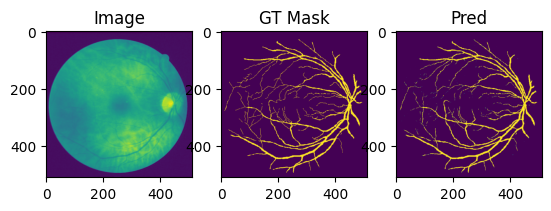

In [56]:
# 첫 배치로 진단

# del img, mask, pred, loss, dice 
img, mask = next(iter(train_dataloader))
pred = model(img.cuda())
loss, dice = dice_loss(pred, mask.cuda())

print(f"1. Mask 비율: {mask.mean():.3f}")
print(f"2. Pred sigmoid: {torch.sigmoid(pred).mean():.3f}")
print(f"3. Dice: {dice:.3f}")
print(f"4. 상관관계: {(pred.cpu() * mask.cpu()).mean():.3f}")

# 시각화
plt.subplot(131); plt.imshow(img[0,0]); plt.title('Image')
plt.subplot(132); plt.imshow(mask[0,0]); plt.title('GT Mask')
plt.subplot(133); plt.imshow(torch.sigmoid(pred.cpu().detach())[0,0]); plt.title('Pred')
plt.show()


In [10]:
def dice_loss(pred, target, smooth = 1e-5):
    '''
    - pred : 모델 출력 logit 텐서, (B,1,H,W) 형태
    - target : 정답 마스크, 1/0 텐서, (B,1,H,W) 형태
    - smooth : 분모가 0이 되는 걸 방지하는 아주 작은 상수 
    # 
    '''

    # target의 값의 범위
    # pred의 값의 범위 
    bce = F.binary_cross_entropy_with_logits(pred, target,reduction = 'mean')
    # print(f'전{ pred.grad_fn}')

    pred = torch.sigmoid(pred)
    # print(f'후 { pred.grad_fn}')

    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))

    dice = 2.0 * (intersection + smooth) / (union + smooth ) # 클수록 좋음 
    dice_loss = 1.0 - dice # 작을 수록 좋음 
    total_loss = bce + dice_loss

    return total_loss.mean(), dice.mean()

In [11]:
if os.path.isfile('/kaggle/working/model.pt'):
    print(f'저장된 모델이 존재합니다.')
    checkpoint = torch.load('/kaggle/working/model.pt',weights_only=False)
    print(checkpoint.keys())
    model.load_state_dict(checkpoint['model'])
    train_loss_all = (checkpoint['loss'])
    train_dice_all = (checkpoint['dice'])

In [50]:
def save_checkpoint(model,loss,dice):
    torch.save({
        'model' : model.state_dict(),
        'loss' : loss,
        'dice' : dice
    }, './model_no_early_stop.pt')


In [53]:
# 실제 데이터로 모델 돌려보기


if os.path.isfile('/kaggle/working/model_no_early_stop.pt'):
    print(f'저장된 모델이 존재합니다.')
    checkpoint = torch.load('/kaggle/working/model_no_early_stop.pt',weights_only=False)
    print(checkpoint.keys())
    model.load_state_dict(checkpoint['model'])
    train_loss_all = (checkpoint['loss'])
    train_dice_all = (checkpoint['dice'])
    
for epoch in range(20):
    model.train()    
    train_losses = []
    train_dices = []
    lrs = []
    for imgs,masks in train_dataloader:
        
        imgs = imgs.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        pred = model(imgs)
        
        train_loss,train_dice = dice_loss(pred,masks)
        # RuntimeError: all elements of target should be between 0 and 1
     
        train_loss.backward()
        optimizer.step()
        
        train_losses.append(train_loss.item())
        train_dices.append(train_dice.item())
    
    print(f'현재 lr : {optimizer.param_groups[0]["lr"]}')
    scheduler.step()
    lrs.append(optimizer.param_groups[0]["lr"])


    # 검증 모드 
    model.eval()
    val_losses = []
    val_dices = []
    best_thresh, best_dice = 0.3, 0
    for imgs,masks in val_dataloader:
        with torch.no_grad():
            total_val_loss, total_val_dice = 0,0 
            imgs = imgs.to(device)
            masks = masks.to(device)
            pred = model(imgs)
            # for t in np.arange(0.25, 0.7, 0.01):
            #     pred_binary = (pred_sigmoid>t).float()
            #     val_loss,val_dice = dice_loss(pred_binary,masks)
            #     if val_dice > best_dice:
            #         best_thresh, best_dice = t, val_dice
            # print(f'best threshold :{best_thresh}, val dice :{best_dice}')
            val_loss, val_dice = dice_loss(pred,masks)
            val_losses.append(val_loss.item())
            val_dices.append(val_dice.item())

    model.train()
    print(f'Epoch {epoch+1}, train Loss: {np.mean(train_losses):.4f}, train Avg Dice : {np.mean(train_dices):.4f}, val loss : {np.mean(val_losses):.4f}, val dice : {np.mean(val_dices):.4f}')
    train_loss_all.append(np.mean(train_losses))
    val_loss_all.append(np.mean(val_losses))
    train_dice_all.append(np.mean(train_dices))
    val_dice_all.append(np.mean(val_dices))
    early_stopping(val_loss=np.mean(val_losses),model=model)
    # if early_stopping.early_stop:
    #     break
        
save_checkpoint(model,train_loss_all, train_dice_all)

저장된 모델이 존재합니다.
dict_keys(['model', 'loss', 'dice'])
현재 lr : 0.0008170728068875465
Epoch 1, train Loss: 0.0007, train Avg Dice : 0.9994, val loss : 0.5862, val dice : 0.7835
Early Stopping counter: 37 out of 5
현재 lr : 0.0008170728068875465
Epoch 2, train Loss: 0.0006, train Avg Dice : 0.9995, val loss : 0.5876, val dice : 0.7839
Early Stopping counter: 38 out of 5
현재 lr : 0.0008007313507497956
Epoch 3, train Loss: 0.0006, train Avg Dice : 0.9995, val loss : 0.5874, val dice : 0.7840
Early Stopping counter: 39 out of 5
현재 lr : 0.0008007313507497956
Epoch 4, train Loss: 0.0006, train Avg Dice : 0.9995, val loss : 0.5878, val dice : 0.7838
Early Stopping counter: 40 out of 5
현재 lr : 0.0008007313507497956
Epoch 5, train Loss: 0.0006, train Avg Dice : 0.9995, val loss : 0.5892, val dice : 0.7839
Early Stopping counter: 41 out of 5
현재 lr : 0.0008007313507497956
Epoch 6, train Loss: 0.0005, train Avg Dice : 0.9995, val loss : 0.5904, val dice : 0.7838
Early Stopping counter: 42 out of 5
현재 lr 

In [17]:
save_checkpoint(model,train_loss_all, train_dice_all)

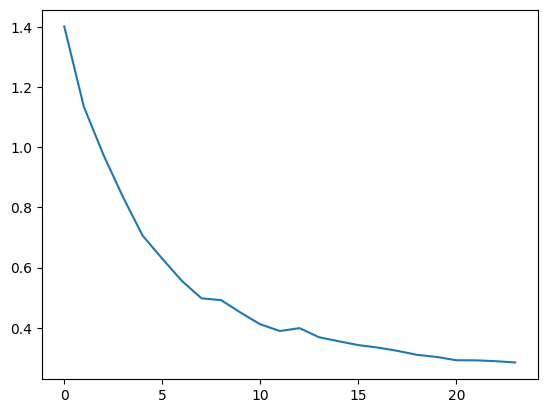

In [35]:
plt.plot(train_loss_all)
plt.plo

0.9590545396010081
0.06615361687727273
1.4527215957641602
0.18099252507090569
163.79804229736328 1.5364644527435303


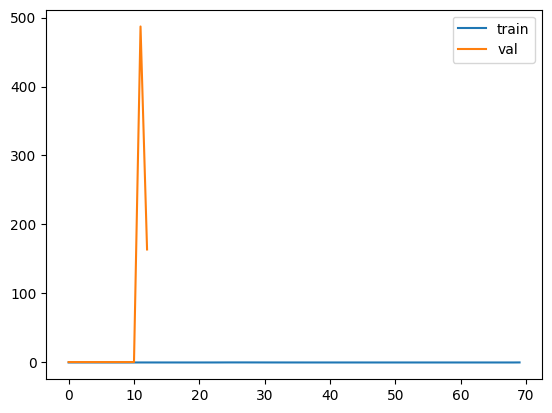

In [55]:
plt.plot(train_loss_all[60:],label='train')
plt.plot(val_loss_all[60:],label='val')
plt.legend()

# 총 80번 학습 돌림 

print(train_dice_all[-1]) # 0.7948364814122518 
print(train_loss_all[-1]) # 0.3024118095636368
print(train_loss_all[0])  # 1.4200892647107441

print(val_dice_all[-1]) # 0.7366564273834229
print(val_loss_all[-1], val_loss_all[0]) # 0.3911687433719635, 1.5364644527435303




0.9993654092152914
0.0007485694950446486
1.4527215957641602
0.783048689365387
0.5859022736549377 1.5364644527435303


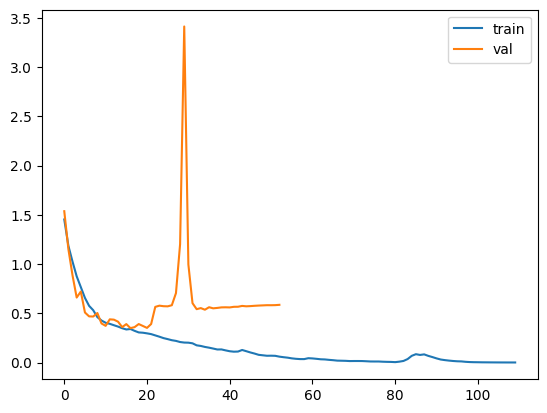

In [52]:
plt.plot(train_loss_all,label='train')
plt.plot(val_loss_all,label='val')
plt.legend()

# 총 80번 학습 돌림 

print(train_dice_all[-1]) # 0.7948364814122518 
print(train_loss_all[-1]) # 0.3024118095636368
print(train_loss_all[0])  # 1.4200892647107441

print(val_dice_all[-1]) # 0.7366564273834229
print(val_loss_all[-1], val_loss_all[0]) # 0.3911687433719635, 1.5364644527435303




0.7948364814122518
0.3024118095636368
1.4200892647107441
0.7366564273834229
0.3911687433719635 1.5364644527435303


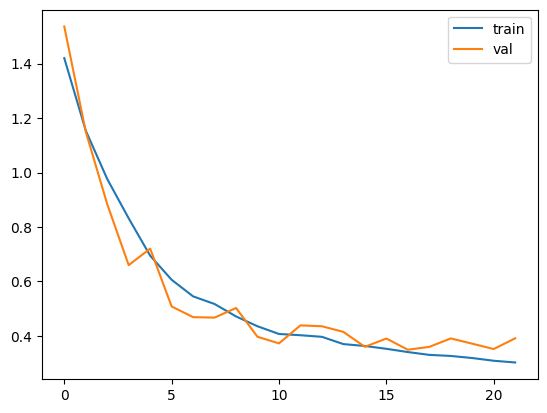

In [46]:
plt.plot(train_loss_all,label='train')
plt.plot(val_loss_all,label='val')
plt.legend()

# 총 80번 학습 돌림 

print(train_dice_all[-1]) # 0.7948364814122518 
print(train_loss_all[-1]) # 0.3024118095636368
print(train_loss_all[0])  # 1.4200892647107441

print(val_dice_all[-1]) # 0.7366564273834229
print(val_loss_all[-1], val_loss_all[0]) # 0.3911687433719635, 1.5364644527435303




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285727].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.959987].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489092].


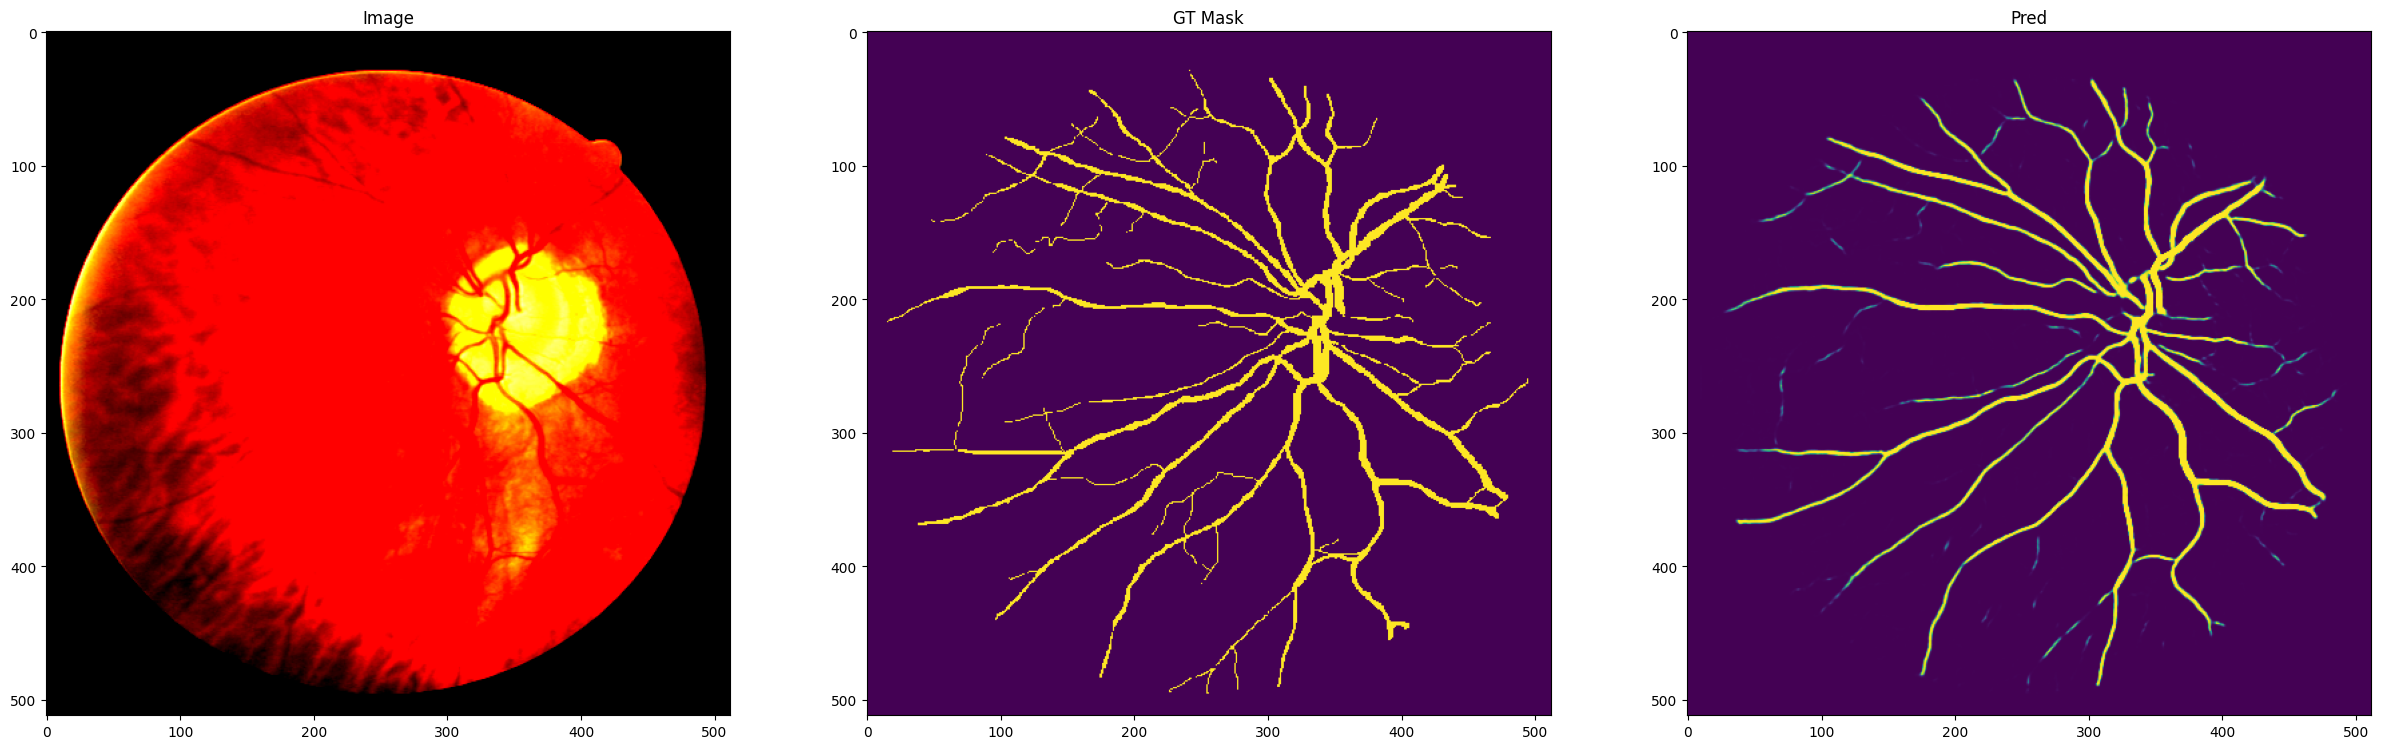

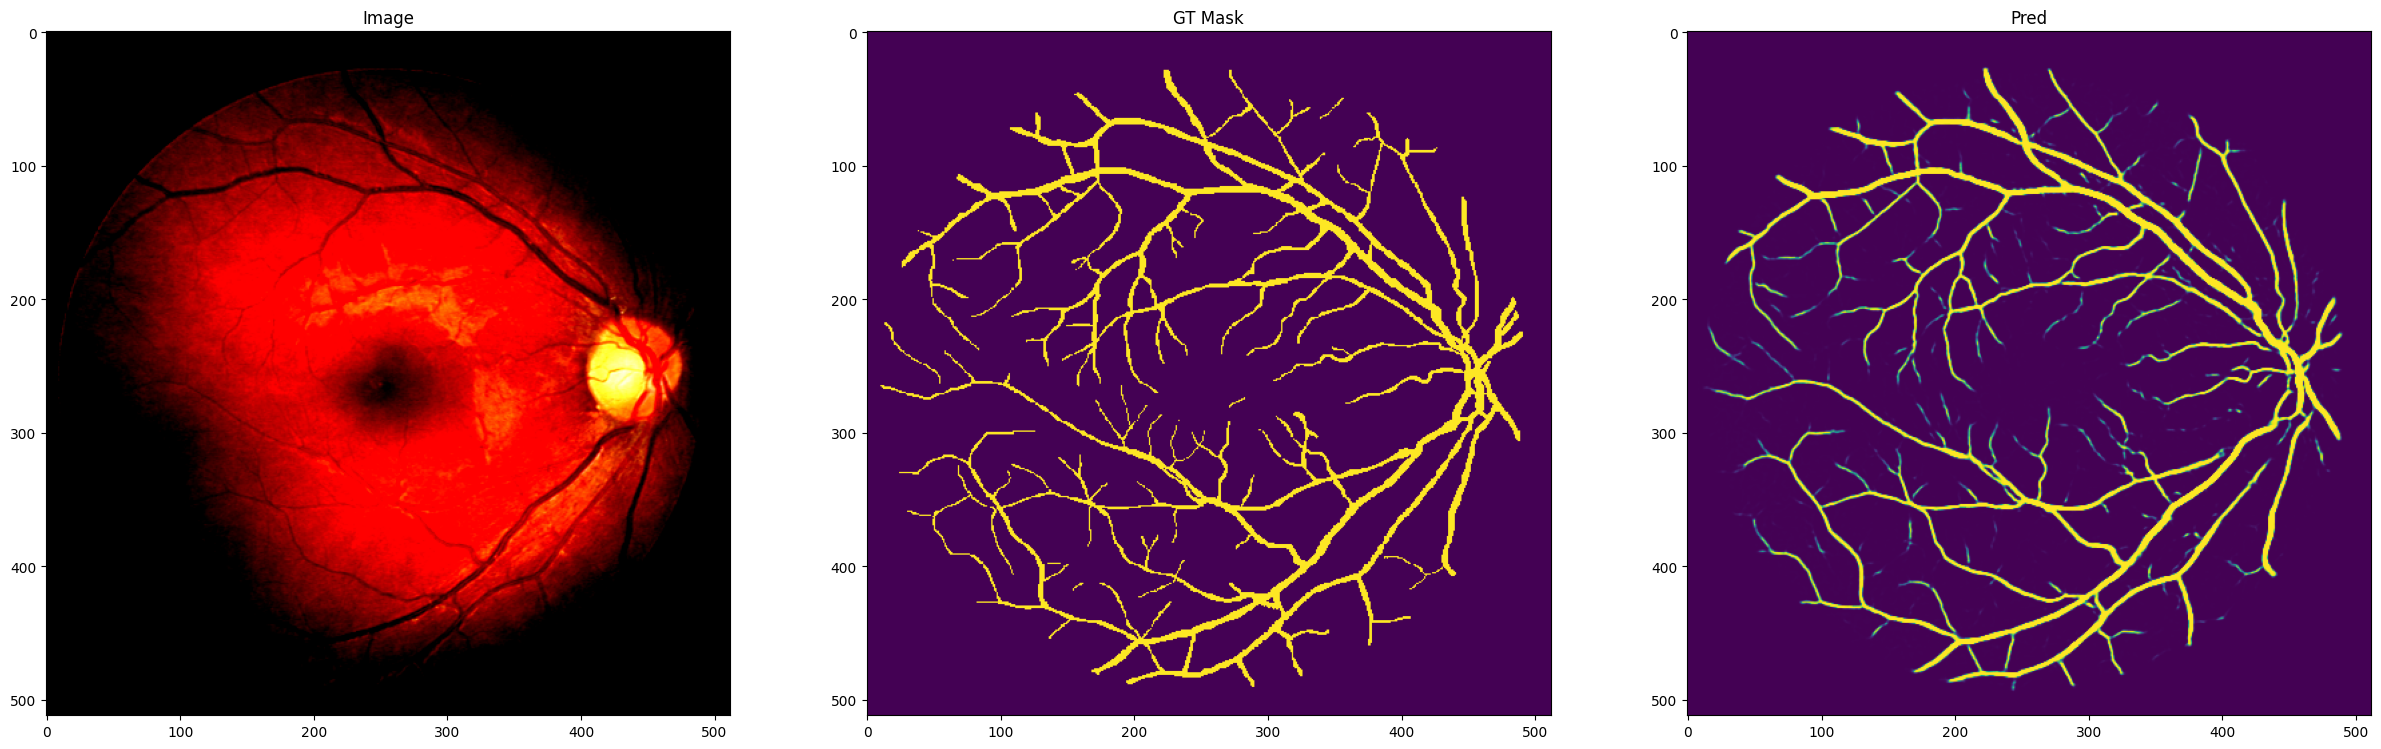

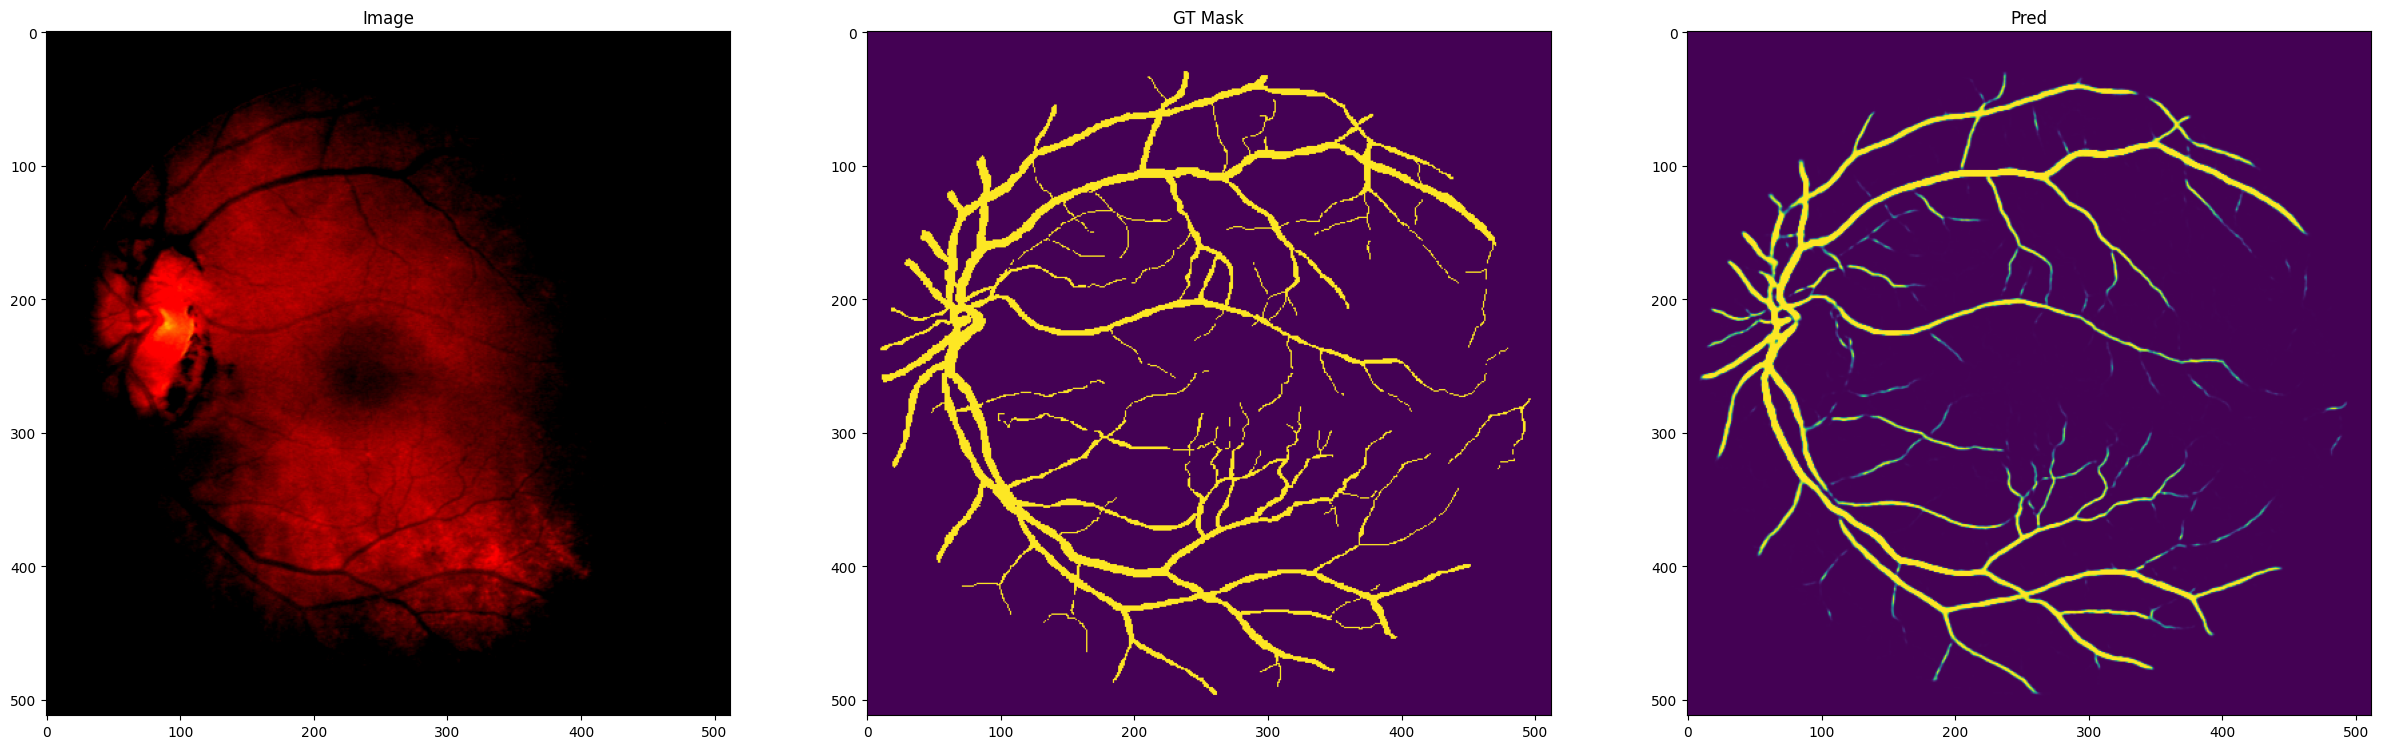

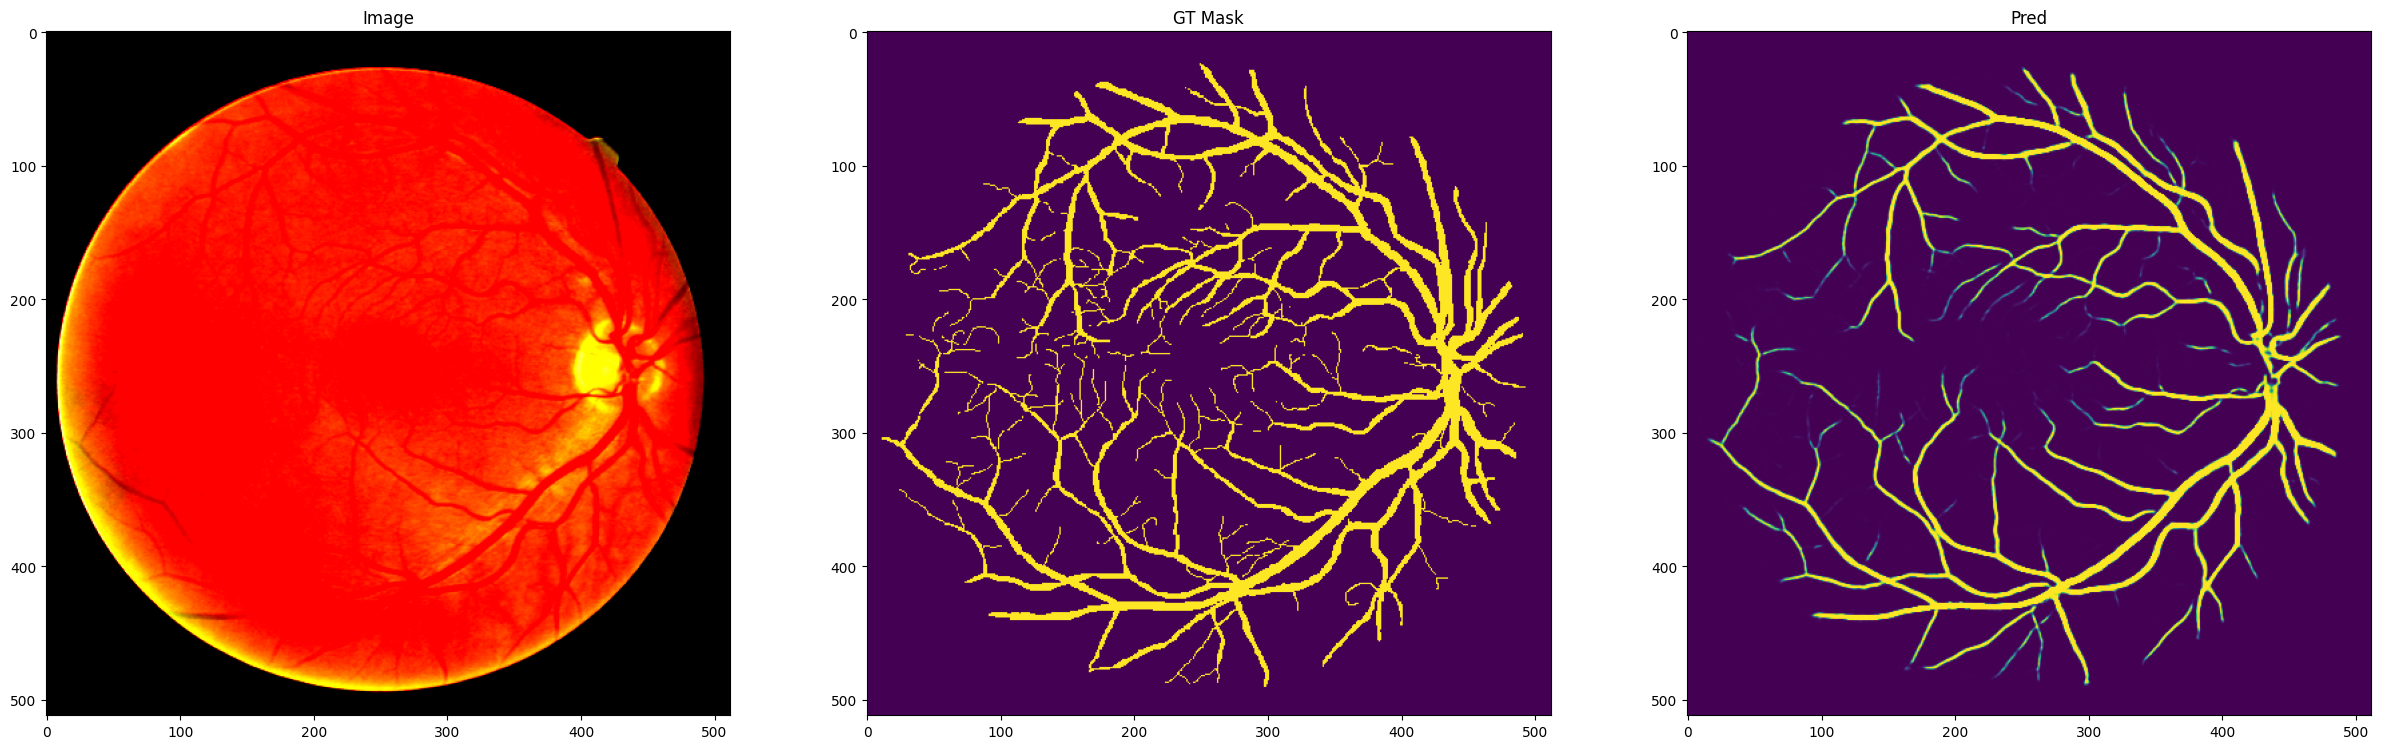

In [47]:
model.eval()
for imgs,masks in val_dataloader:
   with torch.no_grad():
        imgs = imgs.to(device)
        masks = masks.to(device)
        pred = model(imgs)        
        plt.figure(figsize = (30,30))
        plt.subplot(131); plt.imshow(imgs[0].cpu().permute(1,2,0))
        plt.title('Image')
        plt.subplot(132); plt.imshow(masks[0].cpu().permute(1,2,0))
        plt.title('GT Mask')
        plt.subplot(133); plt.imshow(torch.sigmoid(pred.cpu().detach())[0].permute(1,2,0))
        plt.title('Pred')

In [ ]:
# print(early_stopping.val_loss_min)

In [48]:
# 조기 종료


class EarlyStopping():
    def __init__(self,patience = 5, verbose = False, delta = 0.0001, path = '/kaggle/working/checkpoint.pth'):
        self.patience = patience # 몇 번의 에포크를 기다릴지
        self.verbose = verbose 
        self.counter = 0 
        self.best_score = None
        self.early_stop = False
        self.delta = delta # 오차가 개선되었다고 판단하기 위한 최소의 변화량
        self.val_loss_min = np.inf
        self.path = path

    def __call__(self,val_loss, model):
        # 에포크만큼 학습이 반복되면서 best_loss가 갱신되고 best_loss에 진전이 없으면 조기 종료 후 모델을 저장한다.
        score = -(val_loss) # 큰게 좋은거임 

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss,model)
        elif score < self.best_score + self.delta: # 현재 점수보다 가장 좋은 점수 + 변화량 값이 더 크다면  
            self.counter += 1
            print(f'Early Stopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # 현재 점수(-손실)이 더 크다면
            self.best_score = score
            self.save_checkpoint(val_loss,model)
            self.counter = 0
        
        
        # 모델 저장
    def save_checkpoint(self,val_loss, model):
        print(f'Validation loss decreased:{self.val_loss_min}에서 {val_loss}로 Saving model')
        torch.save({
            'model_state_dict':model.state_dict(),
        },self.path)
        self.val_loss_min = val_loss

In [ ]:
# plt.plot(train_loss_all,label = 'train_loss')
# plt.plot(val_loss_all,label='val_loss')
# plt.xlabel('Epoch')  # x축 레이블 추가
# plt.ylabel('Loss')  # y축 레이블 추가
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(train_dice_all,label = 'train_dice')
# plt.plot(val_dice_all,label = 'val_dice')

# plt.xlabel('Epoch')  # x축 레이블 추가
# plt.ylabel('Dice')  # y축 레이블 추가
# plt.legend()
# plt.show()

In [ ]:
# import torch
# import gc

# torch.cuda.empty_cache() 
# gc.collect()

In [ ]:
# # # 모델 출력 차원 확인

# imgs, masks  = next(iter(train_dataloader))
# with torch.no_grad():
#      test_pred = model(imgs.to(device))
#      test_sigmoid = torch.sigmoid(test_pred)
#      test_binary = (test_sigmoid>0.5).float()

#      t_loss, t_dice = dice_loss(test_pred, masks.to(device))
#      print(f'loss {t_loss},dice : {t_dice}')
#      plt.subplot(131)
#      plt.imshow(imgs[0].permute(1,2,0).cpu(),cmap='gray')
#      plt.subplot(132)
#      plt.imshow(test_binary[0].permute(1,2,0).cpu(),cmap='gray')
#      plt.subplot(133)
#      plt.imshow(masks[0].permute(1,2,0).cpu(),cmap='gray')

In [ ]:
# # CLAHE 적용

# # 
# img_rgb = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_training.tif')

# # L 채널 CLAHE
# lab = cv2.cvtColor((img_rgb*255).astype(np.uint8),cv2.COLOR_RGB2LAB)
# l, a,b = cv2.split(lab)

# clahe = cv2.createCLAHE(clipLimit = 3.0, tileGridSize=(12,12))
# l_clahe = clahe.apply(l)
# lab_clahe = cv2.merge([l_clahe,a,b])
# # img_lab_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB) / 255.0

# fig, axes = plt.subplots(1,3,figsize=(15,5))
# axes[0].imshow(img_rgb)
# axes[0].set_title('Original RGB')

# axes[1].imshow(l)
# axes[1].set_title('L Channel (Original)')

# axes[2].imshow(img_lab_clahe)
# axes[2].set_title('L Channel CLAHE ✅\n혈관 더 선명!')

In [ ]:
# def remove_outline(pred_binary):
#     pred_np = pred_binary.cpu().squeeze().numpy()
#     pred_uint8 = (pred_np * 255).astype(np.uint8)

#     circles = cv2.HoughCircles(pred_uint8,cv2.HOUGH_GRADIENT,1,20,
#                             param1=60,param2=15,minRadius=235, maxRadius=250)
#     if circles is not None:
#         print(f'circle 있음')
#         circles = np.round(circles[0,:]).astype('int')
#         img_with_circles = pred_np.copy()
#         for(x,y,r) in circles[:1]:
#             top_r = int(r * 1.0)  
#             cv2.circle(img_with_circles, (x, y+15), r, 0.0, thickness=33)

#         plt.figure(figsize=(20,10))
#         plt.subplot(132)
#         plt.imshow(img_with_circles, cmap='gray')
#         pred_clean_np = img_with_circles
#     else:
#         print('circle 없음')
#         pred_clean_np = pred_np
#     return pred_clean_np

In [ ]:
# Prediction

class VesselTestDataset(Dataset):
    def __init__(self, test_img_dir):
        self.img_paths = sorted(glob.glob(f"{test_img_dir}/*.tif"))
        self.transform = T.Compose([
            # 크기만 조정
            T.ToTensor(),
            T.Resize((512,512)),
            T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
        ])
    def __len__(self):
        return len(self.img_paths) # 전체 이미지 개수  = 20개 
    
    def __getitem__(self,idx):
        # 이미지 
        
        img = Image.open(self.img_paths[idx]).convert('RGB')
        return self.transform(img)

test_dataset = VesselTestDataset(TEST_PATH)
test_dataloader = DataLoader(test_dataset,batch_size = 2,shuffle =False)

# # # 훈련 후 모델 예측 (prediction)
# model.eval()
# test1 = Image.open('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/22_training.tif').convert('RGB')
# transform = T.Compose([
#         T.Resize((512,512)),
#         T.ToTensor(),
#         T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#     ])

# img_tensor = transform(test1).unsqueeze(0).to(device) # [3, 512, 512]
# print(img_tensor.shape) # torch.Size([1, 3, 512, 512])

# mask = Image.open('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/22_manual1.gif').convert('L')
# mask_tensor = T.Resize((512,512), interpolation=T.InterpolationMode.NEAREST)(T.ToTensor()(mask))

# mask_binary = convert_to_binary_mask(mask_tensor.numpy())
# final_mask =torch.from_numpy(mask_binary)
# print(final_mask.shape)

# with torch.no_grad():
#     pred_logits = model(img_tensor)
#     pred_prob = torch.sigmoid(pred_logits)
#     pred_binary = (pred_prob>0.25).float()
   
#     #test_loss, test_dice = dice_loss(pred_logits,mask)
#     #print(f'dice : {dice}')
    
# # #시각화

# plt.figure(figsize = (20,10))
# plt.subplot(131)
# plt.imshow(test1)
# plt.subplot(132)
# plt.imshow(pred_binary.cpu().squeeze(0).permute(1,2,0),cmap='gray')

# plt.subplot(133)
# plt.imshow(final_mask.permute(1,2,0),cmap='gray')

In [ ]:
# # 모델 출력 차원 확인
# imgs  = next(iter(test_dataloader))
# with torch.no_grad():
#     test_pred = model(imgs.to(device))
#     print(f"모델 출력 shape: {test_pred.shape}")  # [B, ?, H, W]

#     plt.imshow(test_pred[0].cpu().permute(1,2,0),cmap='gray')

In [ ]:
# 모델 저장
def save_checkpoint(model,filepath):
    torch.save({
        'model_state_dict':model.state_dict(),
    },filepath)

    print(f'chekcpoint save : {filepath}')

In [ ]:
# #sobelx = cv2.Sobel(src, ddepth, dx, dy, ksize=3)

# '''
# - src : input image (grayscale 이어야한다.! )
# - ddepth : 출력 이미지의 원하는 깊이 
# - dx : x 방향 미분 - 수평 변화 감지 
# - dy : y 방향 미분 - 수직 변화 감지 
# - ksize : sobel 커널 크기 (홀수여야한다)

# '''

# train_img_rgb = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_training.tif')
# train_img_gray = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_training.tif',0) #cv2.IMREAD_GRAYSCALE = 0 

# train_img_tensor = T.ToTensor()(train_img_rgb).unsqueeze(0).to(device)
# model.eval()
# with torch.no_grad():
#     pred = model(train_img_tensor)
# plt.subplot(131)
# plt.imshow(pred,cmap='gray')

# # outline_mask = create_retinal_outline(train_img_gray)

# clean_vessel = pred.cpu() * (1 - outline_mask)

# plt.subplot(132)
# plt.imshow(outline_mask>230) # 밝기 값이 230 이상인 애들 

# plt.colorbar()

# plt.subplot(133)
# plt.imshow(clean_vessel)


# # conver to uint8

# #plt.imshow(gradient_magnitude,cmap='gray')

# # gradient_binary = (gradient_magnitude>0).astype(int)
# # result = train_img - (gradient_binary)

# # plt.imshow(result,cmap='gray')

In [ ]:
# outline_mask = create_retinal_outline(train_img_gray)
# print(train_img_gray) # numpy.ndarray

# outline_binary = (outline_mask>=255).astype(np.float64)
# plt.imshow(outline_binary,cmap='gray')



In [ ]:
# def create_retinal_outline_batch(imgs_tensor):
    
#     # 배치 RGB 이미지 
#     batch_fov = []
#     print(f'imgs_tensor size : {imgs_tensor.shape}')

#     for b in range(imgs_tensor.shape[0]):
#         img_np = imgs_tensor[b].cpu().permute(1,2,0).numpy()
#         gray = cv2.cvtColor((img_np* 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
#         boundary = create_retinal_outline(gray)
#         fov_mask = 1.0 - (boundary > np.percentile(boundary, 90)).astype(np.float32)
#         batch_fov.append(torch.from_numpy(fov_mask))
   
#     return  torch.cat(batch_fov).to(imgs_tensor.device)

In [ ]:
# def create_retinal_outline(img):
#     sobelx = cv2.Sobel(img,cv2.CV_64F, 1, 0, ksize = 3)
#     sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize = 3) # Vertical edges
    
#     gradient_magnitude = cv2.magnitude(sobelx,sobely)
#     gradient_magnitude = cv2.convertScaleAbs(gradient_magnitude)

#     return gradient_magnitude

In [ ]:
def load_model(model):
    try:
        checkpoint = torch.load('/kaggle/working/checkpoint.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        
    except FileNotFoundError:
        print("Checkpoint file not found")
        
    return model  

In [ ]:
# Create Submission File
import pandas as pd
# 
def create_run_length(y_pred):
    dots = np.where(y_pred.flatten() == 1)[0]  # 1인 픽셀 인덱스들
    # 예: [2,3,4,7,8] (flatten된 1차원 배열에서)
    
    run_lengths = []
    prev = -2  # 이전 끝 위치 (-2로 초기화)
    
    for b in dots:  # 각 1 픽셀 순회
        if (b > prev + 1):  # 연속 안됨 → 새 run 시작
            run_lengths.extend((b+1, 0))  # (시작위치, 길이=0) 추가
        run_lengths[-1] += 1  # 마지막 길이 +1
        prev = b  # 이전 끝 갱신
    
    output = ' '.join([str(r) for r in run_lengths])  # 문자열 변환
    return output

def read_test_images():
    filenames = glob.glob(os.path.join(TEST_PATH, '*.tif'))
    filenames.sort()
    test_images = []
    for file_name in filenames:
        image = PIL.Image.open(file_name).resize(IMAGE_SIZE)   
        tensor = T.ToTensor()(image)
        test_images.append(tensor)
    return test_images
    

def make_predictions():
    model = VGG16Unet(input_shape=(512,512,3))
    model = load_model(model)
    model.to(device)
    test_dataset = VesselTestDataset(TEST_PATH)
    test_dataloader = DataLoader(test_dataset,batch_size = 2,shuffle = False)

    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in test_dataloader:
            batch = batch.to(device)
            pred = torch.sigmoid(model(batch))
            predictions.append(pred.cpu())

            # outline_mask = create_retinal_outline_batch(batch)
    predictions = torch.cat(predictions, dim=0)
    submission = "Id,Predicted\n" # 헤더 

    
    with open("submission.csv", "w") as file:
        for i,pred in enumerate(predictions):        
            pred_prob = pred.cpu()
            pred_binary = (pred_prob>0.35).float() # 0.5
           # print(pred_binary.sum())
            # plt.imshow(pred_binary.permute(1,2,0),cmap='gray')
            rle = create_run_length(pred_binary) 
    
            # submission.append([str(i+1),rle])
        # pd.DataFrame(submission).to_csv('/kaggle/working/submission.csv',index=False)
            submission += str(i) + "," + rle + "\n"
        file.write(submission)
        print('완료')

save_checkpoint(model,'/kaggle/working/checkpoint.pth')
make_predictions()

In [ ]:
# print(pd.read_csv('/kaggle/working/submission.csv').head())

RuntimeError: Given transposed=1, weight of size [512, 256, 2, 2], expected input[1, 256, 64, 64] to have 512 channels, but got 256 channels instead

512 채널 입력을 기대하는데 256 채널이 들어왔따! 

In [ ]:
# transform = CropCenterTransform(target_size = (256,256), center_fraction = 0.5)

# train_img = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_training.tif')
# train_mask = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_manual1.gif')

# train_img = T.ToTensor()(train_img)
# train_mask = T.ToTensor()(train_mask)
# img,mask = transform(train_img,train_mask)
# # TypeError: Invalid shape (3, 256, 256) for image data
# # img : B,H,W 순서
# #시각화를 위해서는 W,H,B 순서야함 

# clahe = CLAHEApplication()
# img_clahed , mask = clahe(img,mask)
# plt.subplot(121)
# plt.imshow(img.permute(1,2,0),cmap='gray')
# plt.subplot(122)
# plt.imshow(img_clahed.permute(1,2,0), cmap='gray')

In [ ]:
# pipeline = AugmentationPipeline()

# train_img = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_training.tif')
# train_mask = cv2.imread('/kaggle/input/competitions/sai-vessel-segmentation2/all/train/21_manual1.gif')

# train_img = T.ToTensor()(train_img)
# train_mask = T.ToTensor()(train_mask)



# img, mask = pipeline(train_img, mask_image)

# plt.subplot(121)
# plt.imshow(img)

# plt.subplot(122)
# plt.imshow(mask)

In [ ]:
# dataset = VesselDataset(TRAIN_PATH,TRAIN_PATH)
# dataset[0][0].shape # (584, 565, 3)

# print(dataset[0])
# plt.imshow(dataset[0][1]) # 0번째가 원본 이미지, 1번째가 마스크 이미지임! 

In [ ]:

# # 테스트 예측 확인
# train_imgs, train_masks  = next(iter(train_dataloader))
# with torch.no_grad():
#     train_img = train_imgs[0].unsqueeze(0).to(device)

#     # print(train_img.shape) # torch.Size([1, 3, 256, 256])

#     # 흑백 이미지 
#     # 텐서 -> pil 이미지 얻기 
#     train_img_pil = T.ToPILImage()(train_img.squeeze(0))
#     train_img_gray = T.Grayscale()(train_img_pil) 
#     train_img_gray_tensor = T.ToTensor()(train_img_gray)

#     # clahe 적용 
#     # clahe = CLAHEApplication()
#     # img_clahed , mask = clahe(train_imgs[0],train_masks[0])

#     # 모델 예측
#     pred = model(train_img)
#     pred_sigmoid = torch.sigmoid(pred.cpu())
    
#     # pred_binary_0_3 = (pred_sigmoid > 0.3).float()
#     # pred_binary_0_35 = (pred_sigmoid > 0.35).float()
#     # pred_binary_0_38 = (pred_sigmoid > 0.38).float()
#     # pred_binary_0_4 = (pred_sigmoid > 0.4).float()
#     # pred_binary_0_45 = (pred_sigmoid > 0.45).float()

#     # plt.figure(figsize = (20,10))

#     # plt.subplot(151)
#     # plt.title('threshold 0.3')
#     # plt.imshow(pred_binary_0_3.squeeze(0).permute(1,2,0),cmap='gray')

#     # plt.subplot(152)
#     # plt.title('threshold 0.35')
#     # plt.imshow(pred_binary_0_35.squeeze(0).permute(1,2,0),cmap='gray')

#     # plt.subplot(153)
#     # plt.title('threshold 0.38')
#     # plt.imshow(pred_binary_0_38.squeeze(0).permute(1,2,0),cmap='gray')

#     # plt.subplot(154)
#     # plt.title('threshold 0.4')
#     # plt.imshow(pred_binary_0_4.squeeze(0).permute(1,2,0),cmap='gray')

#     # plt.subplot(155)
#     # plt.title('threshold 0.45')
#     # plt.imshow(pred_binary_0_45.squeeze(0).permute(1,2,0),cmap='gray')

    
#     # 흑백으로 변환 후 sobel 적용하기 
#     p = train_img.squeeze(0).permute(1,2,0).cpu().numpy()

#     p_gray = cv2.cvtColor((p*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
#     p_gray = p_gray.astype(np.float32) / 255.0  # [512,512]

#     # pred_outline_binary = (pred_outline>0.5).astype(np.float64)
#     final_binary = (pred_prob.cpu()>0.5).numpy().astype(np.float64)

### Dice coef

-예측값과 정답값 사이의 겹치는 영역에 2를 곱하고 예측값과 정답값 영역을 합한 것으로 나눠준다. 

- binary segmentation map에 적용할 때는 F1 score와 동일해짐

- > https://deep-learning-study.tistory.com/706

### Dice 값이 저조한 문제 해결

In [ ]:
# for imgs, masks in train_dataloader:
#     print(f"Mask min/max: {masks.min():.4f}/{masks.max():.4f}")
#     print(f"Mask unique: {torch.unique(masks)}")
#     print(f"FG ratio: {masks.mean():.4f}")
#     break


In [ ]:
# imgs, masks = next(iter(train_dataloader))
# with torch.no_grad():
#     pred = model(imgs.cuda())
#     pred_sig = torch.sigmoid(pred)
#     print(f"Pred logit: {pred.min():.2f}~{pred.max():.2f}")
#     print(f"Pred sig mean/std: {pred_sig.mean():.3f}/{pred_sig.std():.3f}")